Ride Demand Zone Classification — Advanced
Machine Learning Project Guide


Problem Statement


Objective: Build a multiclass machine learning model that predicts ride demand levels in different
city zones. The demand level is categorized as Low, Medium, or High. Business Context:
Ride-hailing platforms must anticipate demand patterns across city zones to efficiently allocate
drivers, reduce waiting times, manage surge pricing, and optimize ride fulfillment rates. This project
simulates a real-world demand forecasting classification system using historical ride patterns,
weather conditions, traffic indicators, and zone characteristics.

Data Dictionary


Column Description
record_id Unique record identifier
timestamp Observation timestamp
zone_id Zone identifier
zone_type Type of urban zone
hour_of_day Hour extracted from timestamp (0-23)
day_of_week Day of week where Monday=0
month Month number
is_weekend 1 if Saturday/Sunday else 0
is_holiday 1 if holiday/festival date else 0
peak_hour_flag 1 for commute-heavy hours
weather_condition Observed weather category
temperature_c Temperature in Celsius
rainfall_mm Rainfall in millimeters
humidity_pct Humidity percentage
traffic_level Traffic severity bucket
avg_vehicle_speed_kmph Average vehicle speed in km/h
road_congestion_score Congestion score from 0-100
public_transport_availability Zone public transport accessibility index
event_nearby_flag 1 if nearby event likely to affect demand
event_type Nearby event category or No Event
population_density_index Relative population density index
office_density_index Relative office density index
shopping_density_index Relative shopping density index
tourist_spot_flag 1 if zone is a tourist hotspot
driver_availability Estimated available drivers in zone
previous_hour_ride_count Historical ride count for previous hour
same_hour_last_day_ride_count Historical ride count for same hour yesterday
same_hour_last_week_ride_count Historical ride count for same hour last week
app_open_count Approximate ride-app opens/searches
ride_price_surge_multiplier Estimated surge multiplier
demand_zone Target class: Low/Medium/High


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Downloads/ride_demand_zone_classification_dataset.csv")

In [3]:
df.head()

,record_id,timestamp,zone_id,zone_type,hour_of_day,day_of_week,month,is_weekend,is_holiday,peak_hour_flag,...,office_density_index,shopping_density_index,tourist_spot_flag,driver_availability,previous_hour_ride_count,same_hour_last_day_ride_count,same_hour_last_week_ride_count,app_open_count,ride_price_surge_multiplier,demand_zone
0,1,2025-10-30 22:00:00,Z021,Suburban,22,3,10,0,0,0,...,12,18,0,22,48,30,31,106,1.22,Low
1,2,2025-05-29 04:00:00,Z004,Commercial,4,3,5,0,0,0,...,88,55,0,67,84,74,41,111,1.00,Medium
2,3,2025-12-24 03:00:00,Z001,Residential,3,2,12,0,0,0,...,25,20,0,29,65,47,60,109,1.13,High
3,4,2025-12-04 22:00:00,Z024,Mixed Use,22,3,12,0,0,0,...,58,52,0,53,68,53,40,113,1.12,Medium
4,5,2025-08-16 02:00:00,Z009,Railway,2,5,8,1,0,0,...,35,42,0,57,55,43,45,66,0.92,Medium


In [4]:
df.shape

(10000, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       10000 non-null  int64  
 1   timestamp                       10000 non-null  object 
 2   zone_id                         10000 non-null  object 
 3   zone_type                       10000 non-null  object 
 4   hour_of_day                     10000 non-null  int64  
 5   day_of_week                     10000 non-null  int64  
 6   month                           10000 non-null  int64  
 7   is_weekend                      10000 non-null  int64  
 8   is_holiday                      10000 non-null  int64  
 9   peak_hour_flag                  10000 non-null  int64  
 10  weather_condition               10000 non-null  object 
 11  temperature_c                   10000 non-null  float64
 12  rainfall_mm                     9

In [6]:
df.describe()

,record_id,hour_of_day,day_of_week,month,is_weekend,is_holiday,peak_hour_flag,temperature_c,rainfall_mm,humidity_pct,...,population_density_index,office_density_index,shopping_density_index,tourist_spot_flag,driver_availability,previous_hour_ride_count,same_hour_last_day_ride_count,same_hour_last_week_ride_count,app_open_count,ride_price_surge_multiplier
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9880.000000,9900.000000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,11.575400,2.968300,6.576100,0.278400,0.032400,0.332200,26.257970,1.926417,67.676253,...,58.452500,46.87490,43.754400,0.118400,45.602900,65.688900,48.687400,47.994900,101.609800,1.150201
std,2886.89568,6.914528,1.989545,3.461532,0.448234,0.177069,0.471026,6.219663,4.300886,14.603239,...,13.925981,27.29664,20.406615,0.323097,12.776249,17.122764,15.574895,15.495802,30.459487,0.096479
min,1.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.900000,0.000000,30.000000,...,36.000000,10.00000,15.000000,0.000000,5.000000,13.000000,3.000000,3.000000,10.000000,0.900000
25%,2500.75000,6.000000,1.000000,4.000000,0.000000,0.000000,0.000000,22.600000,0.000000,56.300000,...,48.000000,25.00000,28.000000,0.000000,37.000000,54.000000,38.000000,37.000000,81.000000,1.090000
50%,5000.50000,12.000000,3.000000,7.000000,0.000000,0.000000,0.000000,27.000000,0.000000,66.000000,...,58.000000,38.00000,40.000000,0.000000,45.000000,64.000000,48.000000,47.000000,100.000000,1.160000
75%,7500.25000,18.000000,5.000000,10.000000,1.000000,0.000000,1.000000,30.300000,1.300000,78.800000,...,68.000000,60.00000,57.000000,0.000000,54.000000,75.000000,58.000000,58.000000,121.000000,1.220000
max,10000.00000,23.000000,6.000000,12.000000,1.000000,1.000000,1.000000,45.900000,35.300000,98.000000,...,85.000000,98.00000,85.000000,1.000000,93.000000,128.000000,121.000000,118.000000,228.000000,1.430000


In [7]:
df.isnull().sum()

record_id                           0
timestamp                           0
zone_id                             0
zone_type                           0
hour_of_day                         0
day_of_week                         0
month                               0
is_weekend                          0
is_holiday                          0
peak_hour_flag                      0
weather_condition                   0
temperature_c                       0
rainfall_mm                       120
humidity_pct                      100
traffic_level                       0
avg_vehicle_speed_kmph             80
road_congestion_score               0
public_transport_availability       0
event_nearby_flag                   0
event_type                          0
population_density_index            0
office_density_index                0
shopping_density_index              0
tourist_spot_flag                   0
driver_availability                 0
previous_hour_ride_count            0
same_hour_la

In [8]:
df.duplicated().sum()

np.int64(0)

* Exploratory Data Analysis Tasks


In [9]:
df.shape

(10000, 31)

In [10]:
df.dtypes

record_id                           int64
timestamp                          object
zone_id                            object
zone_type                          object
hour_of_day                         int64
day_of_week                         int64
month                               int64
is_weekend                          int64
is_holiday                          int64
peak_hour_flag                      int64
weather_condition                  object
temperature_c                     float64
rainfall_mm                       float64
humidity_pct                      float64
traffic_level                      object
avg_vehicle_speed_kmph            float64
road_congestion_score             float64
public_transport_availability       int64
event_nearby_flag                   int64
event_type                         object
population_density_index            int64
office_density_index                int64
shopping_density_index              int64
tourist_spot_flag                 

In [11]:
df.isnull().sum()

record_id                           0
timestamp                           0
zone_id                             0
zone_type                           0
hour_of_day                         0
day_of_week                         0
month                               0
is_weekend                          0
is_holiday                          0
peak_hour_flag                      0
weather_condition                   0
temperature_c                       0
rainfall_mm                       120
humidity_pct                      100
traffic_level                       0
avg_vehicle_speed_kmph             80
road_congestion_score               0
public_transport_availability       0
event_nearby_flag                   0
event_type                          0
population_density_index            0
office_density_index                0
shopping_density_index              0
tourist_spot_flag                   0
driver_availability                 0
previous_hour_ride_count            0
same_hour_la

In [12]:
df.duplicated().sum()

np.int64(0)

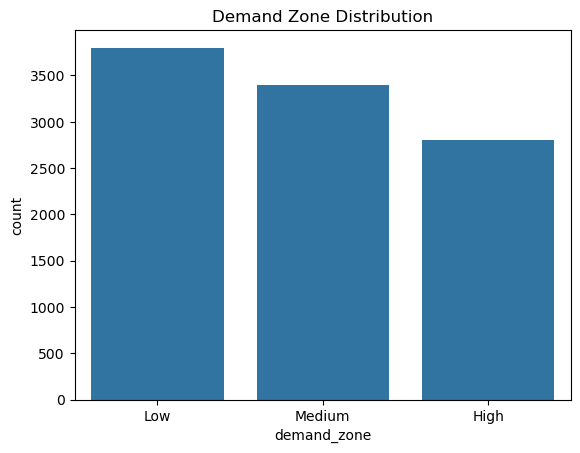

In [13]:
sns.countplot(x='demand_zone', data=df)
plt.title("Demand Zone Distribution")
plt.show()

In [14]:
df.groupby("zone_id")["previous_hour_ride_count"].mean().sort_values(ascending=False).head(10)

zone_id
Z004    83.703980
Z006    80.979167
Z018    80.934884
Z005    80.409524
Z020    79.237374
Z007    78.224090
Z024    74.179104
Z025    73.636364
Z012    67.330769
Z013    66.281796
Name: previous_hour_ride_count, dtype: float64

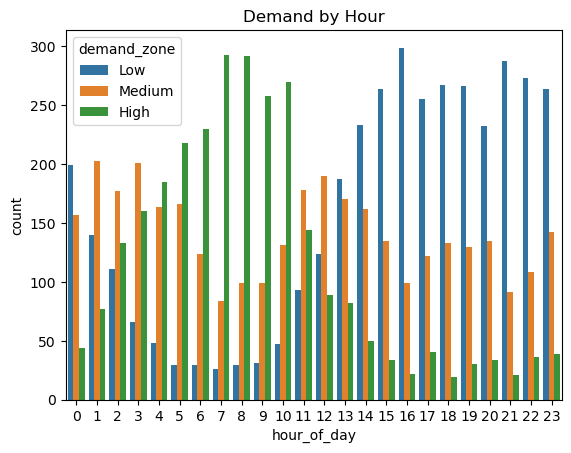

In [15]:
sns.countplot(x='hour_of_day', hue='demand_zone', data=df)
plt.title("Demand by Hour")
plt.show()

In [17]:
hourly_demand = df.groupby("hour_of_day")["previous_hour_ride_count"].mean()

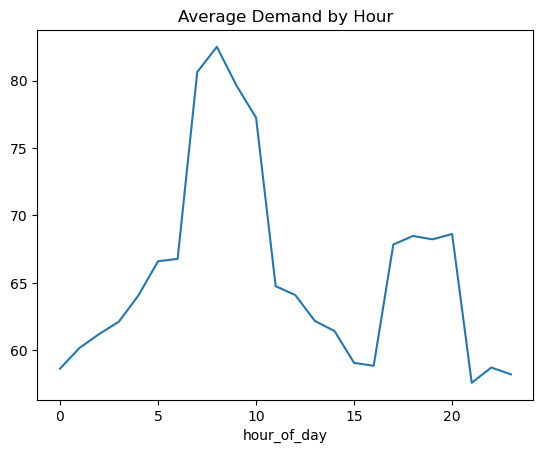

In [19]:
df.groupby("hour_of_day")["previous_hour_ride_count"].mean().plot()
plt.title("Average Demand by Hour")
plt.show()

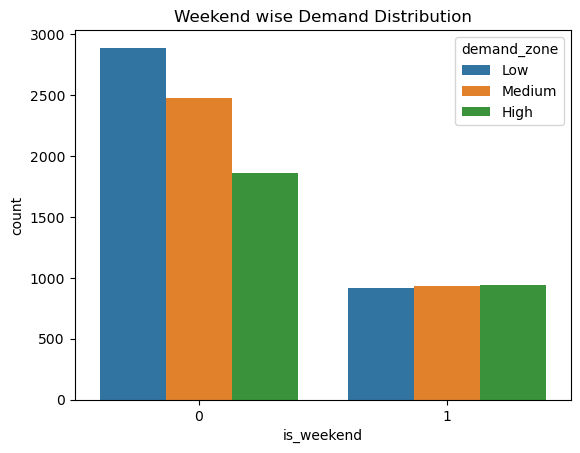

In [21]:
sns.countplot(x='is_weekend', hue='demand_zone', data=df)
plt.title('Weekend wise Demand Distribution')
plt.show()

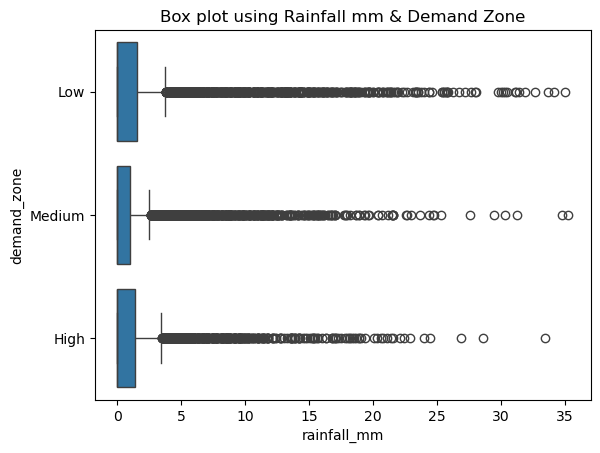

In [24]:
sns.boxplot(x='rainfall_mm', y='demand_zone', data=df)
plt.title('Box plot using Rainfall mm & Demand Zone')
plt.show()

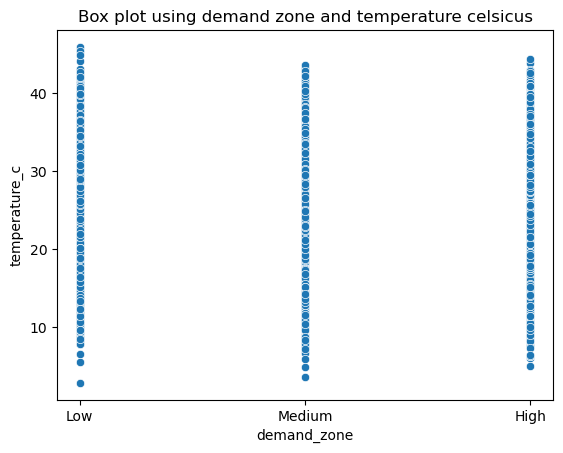

In [25]:
sns.scatterplot(x='demand_zone', y='temperature_c', data=df)
plt.title('Box plot using demand zone and temperature celsicus')
plt.show()

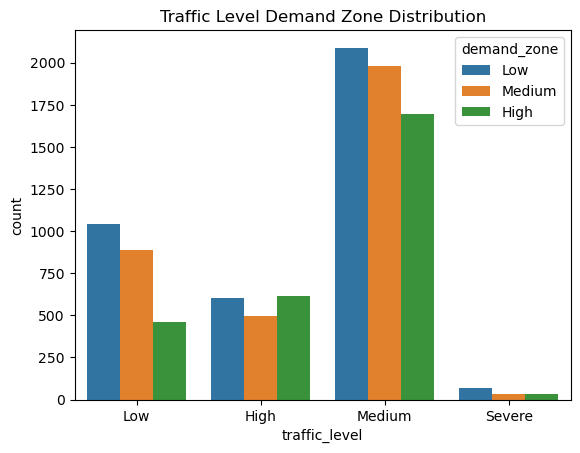

In [26]:
sns.countplot(x='traffic_level', hue='demand_zone', data=df)
plt.title('Traffic Level Demand Zone Distribution')
plt.show()

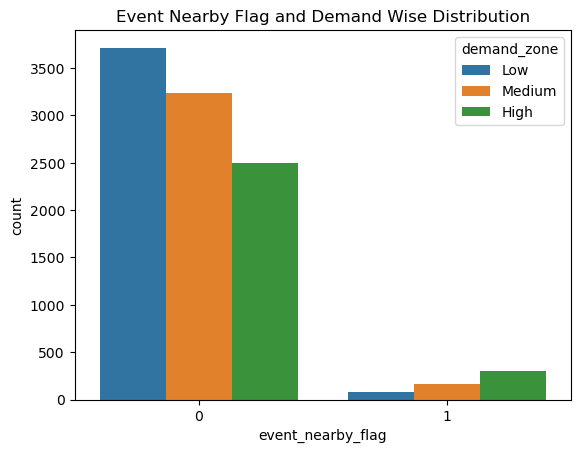

In [28]:
sns.countplot(x='event_nearby_flag', hue='demand_zone', data=df)
plt.title('Event Nearby Flag and Demand Wise Distribution')
plt.show()

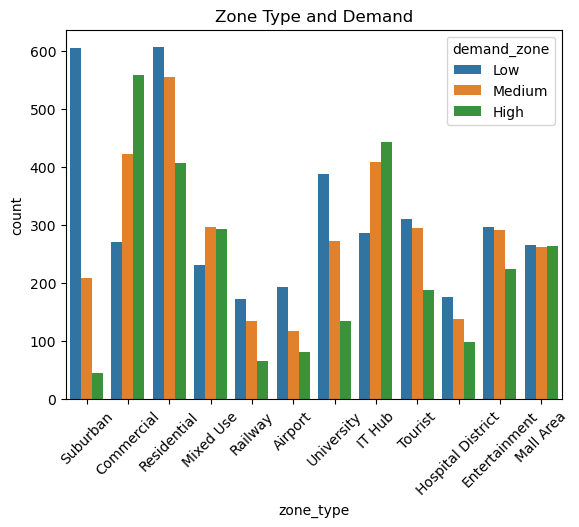

In [29]:
sns.countplot(x='zone_type', hue='demand_zone', data=df)
plt.title('Zone Type and Demand')
plt.xticks(rotation=45)
plt.show()

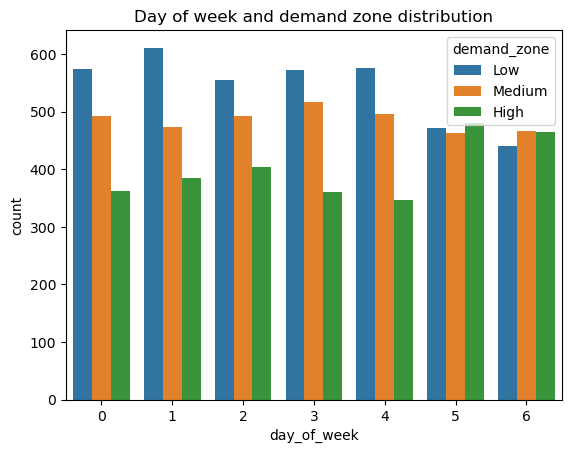

In [33]:
sns.countplot(x='day_of_week', hue='demand_zone', data=df)
plt.title('Day of week and demand zone distribution')
plt.show()

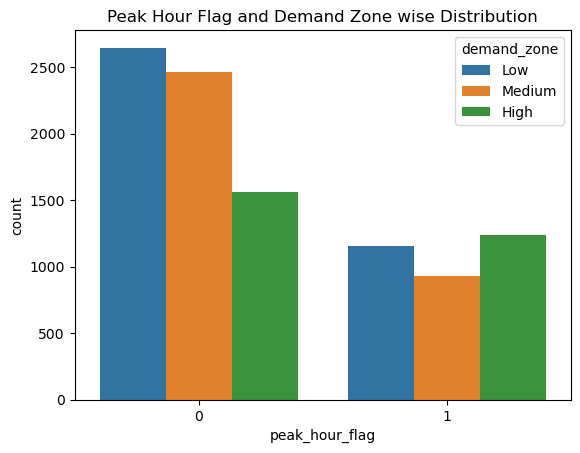

In [34]:
sns.countplot(x='peak_hour_flag', hue='demand_zone', data=df)
plt.title('Peak Hour Flag and Demand Zone wise Distribution')
plt.show()

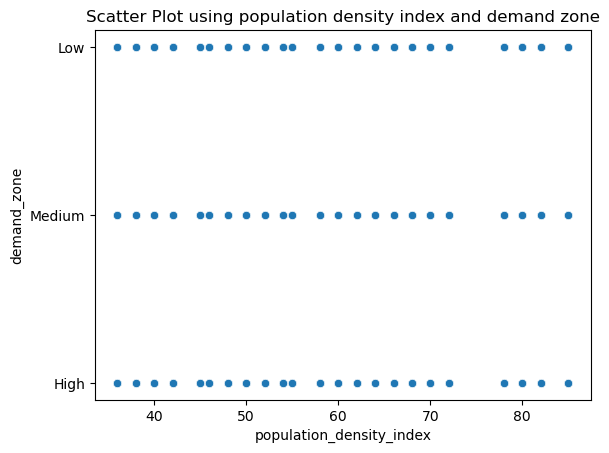

In [35]:
sns.scatterplot(x='population_density_index',y='demand_zone',data=df)
plt.title('Scatter Plot using population density index and demand zone')
plt.show()

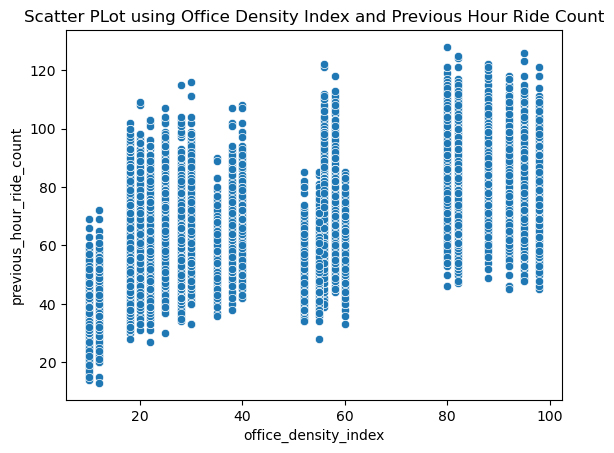

In [36]:
sns.scatterplot(x='office_density_index',y='previous_hour_ride_count',data=df)
plt.title('Scatter PLot using Office Density Index and Previous Hour Ride Count')
plt.show()


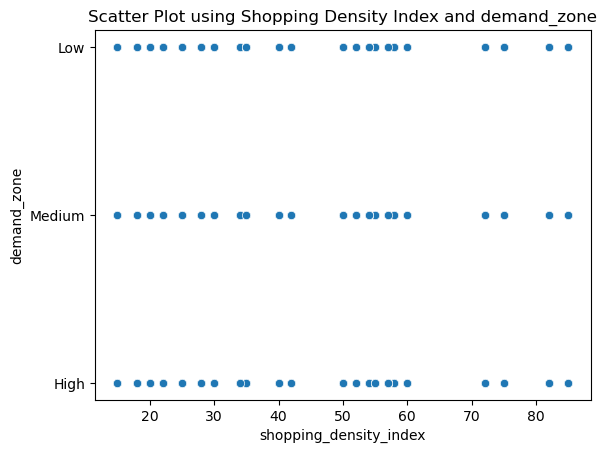

In [37]:
sns.scatterplot(x='shopping_density_index',y='demand_zone',data=df)
plt.title('Scatter Plot using Shopping Density Index and demand_zone')
plt.show()


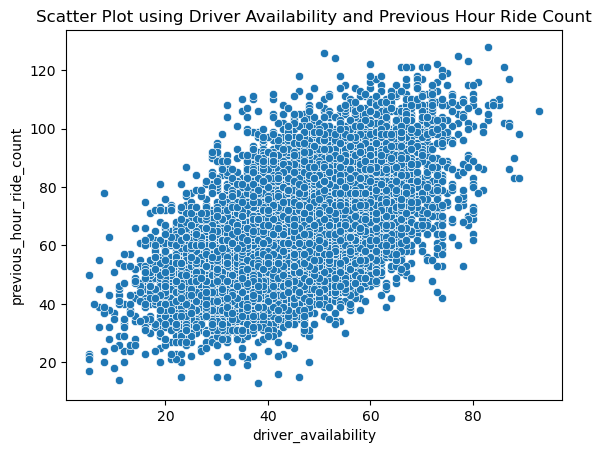

In [38]:
sns.scatterplot(x='driver_availability',y='previous_hour_ride_count',data=df)
plt.title('Scatter Plot using Driver Availability and Previous Hour Ride Count')
plt.show()

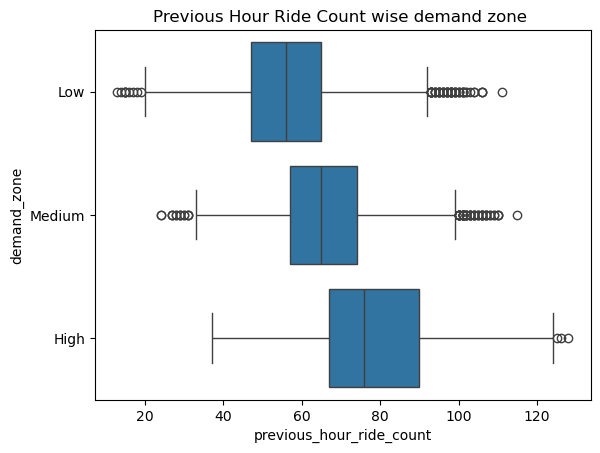

In [4]:
sns.boxplot(x='previous_hour_ride_count', y='demand_zone', data=df)
plt.title('Previous Hour Ride Count wise demand zone ')
plt.show()

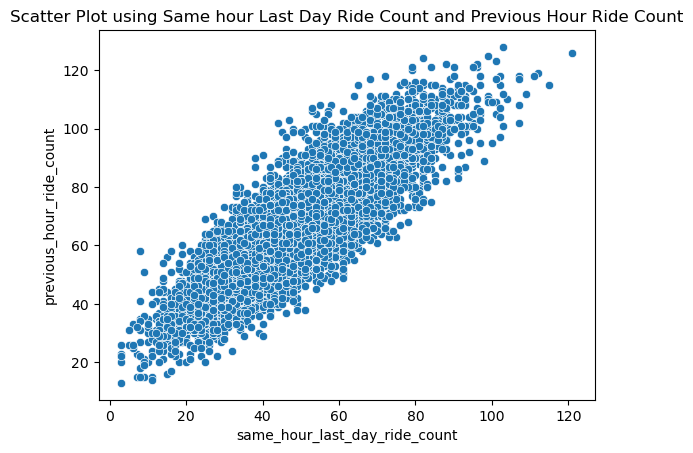

In [5]:
sns.scatterplot(x='same_hour_last_day_ride_count',y='previous_hour_ride_count',data=df)
plt.title('Scatter Plot using Same hour Last Day Ride Count and Previous Hour Ride Count')
plt.show()

In [6]:
df.groupby("zone_id")["road_congestion_score"].mean().sort_values(ascending=False)

zone_id
Z006    47.064062
Z004    46.988308
Z018    46.505581
Z020    46.365657
Z007    46.362465
Z005    45.720714
Z024    42.508955
Z012    42.250513
Z025    41.856699
Z013    41.630424
Z023    41.154722
Z010    39.287500
Z011    38.430273
Z014    38.239842
Z009    37.678016
Z015    37.671325
Z016    37.529808
Z017    37.127586
Z008    36.707161
Z002    34.620305
Z001    34.111047
Z019    33.638889
Z003    33.264493
Z021    29.481840
Z022    29.455632
Name: road_congestion_score, dtype: float64

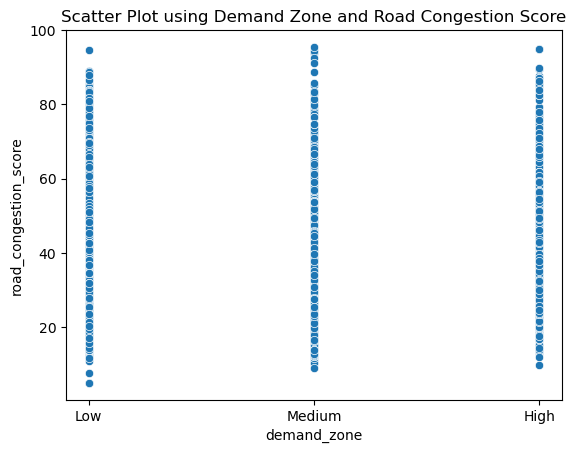

In [7]:
sns.scatterplot(x='demand_zone', y='road_congestion_score',data=df)
plt.title('Scatter Plot using Demand Zone and Road Congestion Score')
plt.show()

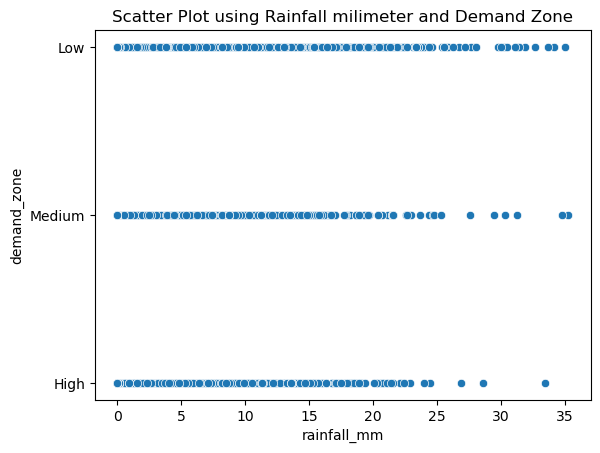

In [8]:
sns.scatterplot(x='rainfall_mm',y='demand_zone', data=df)
plt.title('Scatter Plot using Rainfall milimeter and Demand Zone')
plt.show()

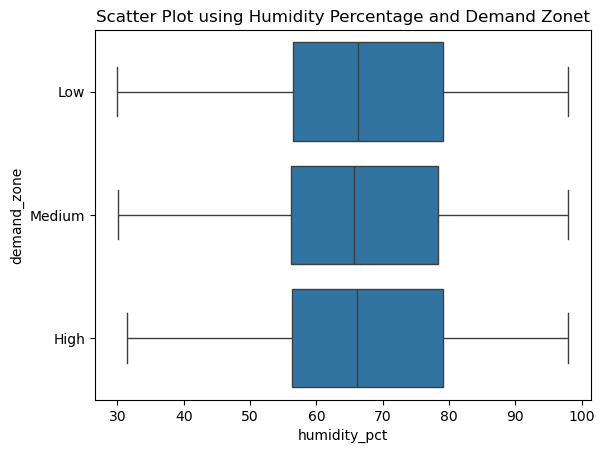

In [9]:
sns.boxplot(x='humidity_pct', y='demand_zone',data=df)
plt.title('Scatter Plot using Humidity Percentage and Demand Zonet')
plt.show()

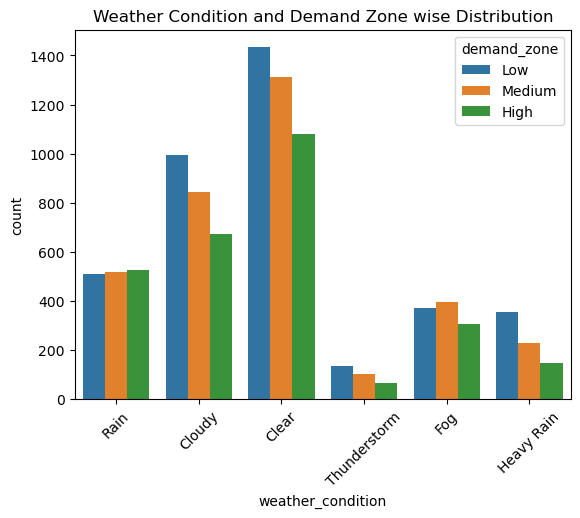

In [10]:
sns.countplot(x='weather_condition', hue='demand_zone', data=df)
plt.xticks(rotation=45)
plt.title('Weather Condition and Demand Zone wise Distribution')
plt.show()

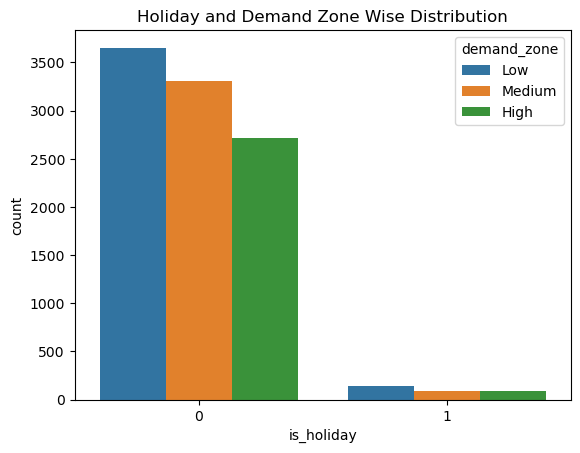

In [11]:
sns.countplot(x='is_holiday', hue='demand_zone', data=df)
plt.title('Holiday and Demand Zone Wise Distribution')
plt.show()


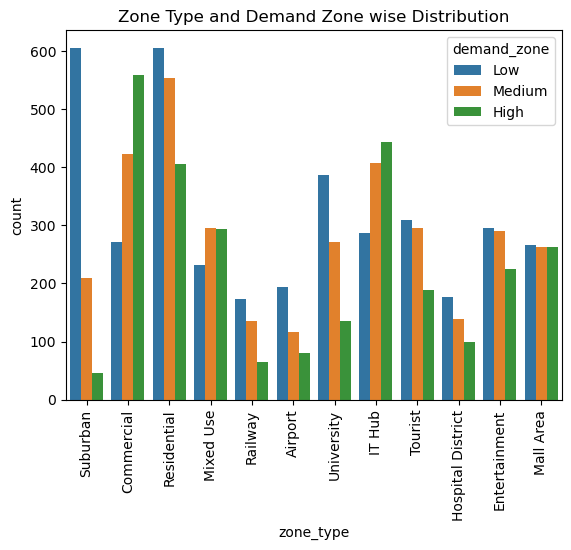

In [12]:
sns.countplot(x='zone_type', hue='demand_zone', data=df)
plt.title('Zone Type and Demand Zone wise Distribution')
plt.xticks(rotation=90)
plt.show()

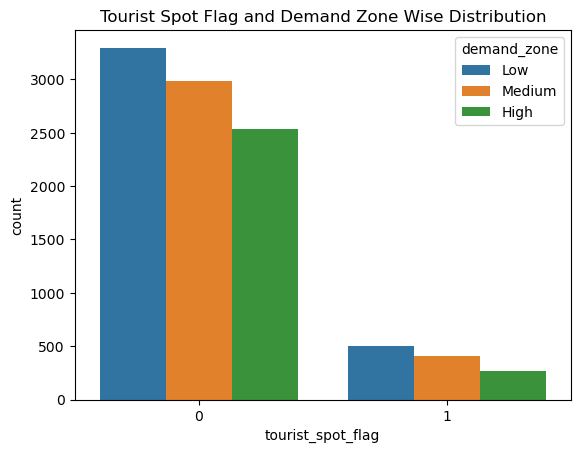

In [13]:
sns.countplot(x='tourist_spot_flag', hue='demand_zone', data=df)
plt.title('Tourist Spot Flag and Demand Zone Wise Distribution')
plt.show()


In [16]:
df.groupby("zone_id")["previous_hour_ride_count"].std().sort_values().head()

zone_id
Z009    8.486112
Z021    9.109366
Z023    9.386223
Z022    9.500019
Z014    9.607324
Name: previous_hour_ride_count, dtype: float64

In [18]:
df.groupby("zone_id")["previous_hour_ride_count"].std().sort_values(ascending=False)

zone_id
Z001    16.245181
Z003    15.842388
Z007    15.504265
Z006    15.469825
Z005    15.455808
Z020    15.354353
Z019    15.238274
Z025    15.237585
Z018    14.917190
Z002    14.679349
Z024    14.381956
Z004    14.321197
Z010    12.778395
Z017    12.152372
Z012    10.924881
Z011    10.918469
Z013    10.806845
Z016    10.434301
Z008     9.986391
Z015     9.788139
Z014     9.607324
Z022     9.500019
Z023     9.386223
Z021     9.109366
Z009     8.486112
Name: previous_hour_ride_count, dtype: float64

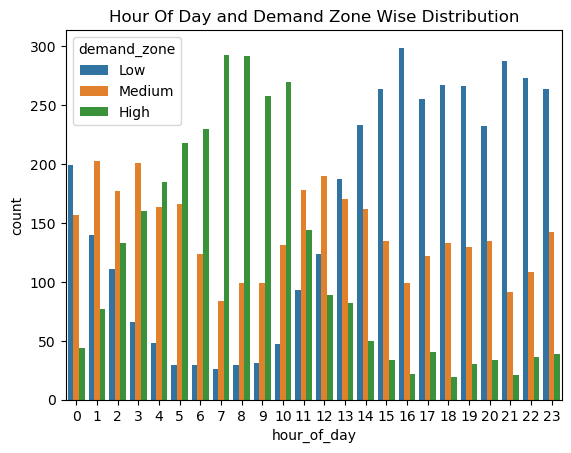

In [20]:
sns.countplot(x='hour_of_day', hue='demand_zone', data=df)
plt.title('Hour Of Day and Demand Zone Wise Distribution')
plt.show()


In [ ]:
sns.countplot(x='is_weekend', data=df)
plt.title('Count Plot Using Weekend')
plt.show()

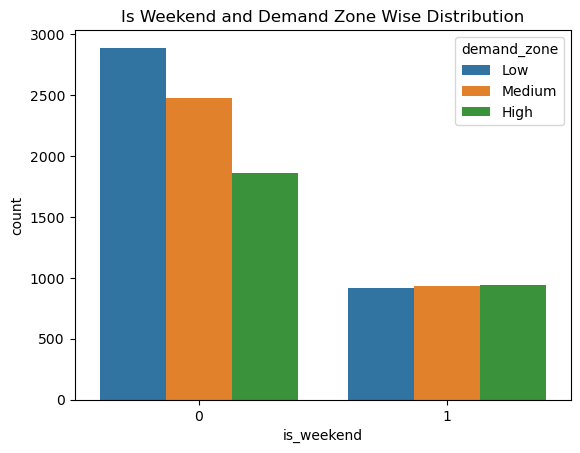

In [21]:
sns.countplot(x='is_weekend', hue='demand_zone', data=df)
plt.title('Is Weekend and Demand Zone Wise Distribution')
plt.show()

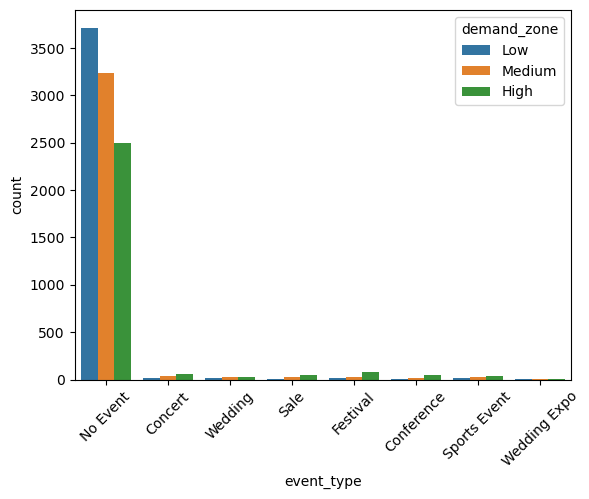

In [22]:
sns.countplot(x='event_type', hue='demand_zone', data=df)
plt.xticks(rotation=45)
plt.show()

In [23]:
numerical_col=df.select_dtypes(include=['int64','float64'])

In [24]:
corr=numerical_col.corr()

In [25]:
corr

,record_id,hour_of_day,day_of_week,month,is_weekend,is_holiday,peak_hour_flag,temperature_c,rainfall_mm,humidity_pct,...,population_density_index,office_density_index,shopping_density_index,tourist_spot_flag,driver_availability,previous_hour_ride_count,same_hour_last_day_ride_count,same_hour_last_week_ride_count,app_open_count,ride_price_surge_multiplier
record_id,1.000000,0.000491,0.007517,-0.002520,-0.002394,0.003195,0.004229,-0.016787,0.001875,-0.007547,...,0.010706,0.014276,0.003315,-0.003167,0.001107,0.012622,0.009471,-0.000561,0.013742,0.017583
hour_of_day,0.000491,1.000000,0.009105,0.002432,0.009006,0.006255,0.197891,0.041011,0.005052,0.009116,...,0.013230,0.008619,-0.006860,-0.014740,-0.056571,-0.071313,-0.232277,-0.048394,-0.052171,0.036303
day_of_week,0.007517,0.009105,1.000000,0.003640,0.787968,-0.028880,0.017748,-0.009437,-0.015937,-0.006474,...,-0.004991,0.007724,0.002853,0.001950,0.017470,0.045117,0.028340,0.198246,0.048403,0.038547
month,-0.002520,0.002432,0.003640,1.000000,0.015930,0.040685,0.021235,-0.022549,0.094933,0.098596,...,-0.014043,-0.014381,-0.003490,0.014835,0.013102,0.017501,0.012447,0.019451,0.021429,0.013078
is_weekend,-0.002394,0.009006,0.787968,0.015930,1.000000,-0.027976,0.022337,-0.002220,-0.016070,-0.003831,...,-0.006549,0.008904,0.006229,-0.003885,0.026502,0.058509,0.043683,0.251823,0.069232,0.051573
is_holiday,0.003195,0.006255,-0.028880,0.040685,-0.027976,1.000000,-0.011551,-0.052668,-0.027452,-0.017445,...,-0.003716,-0.001003,-0.011470,0.009857,0.015635,0.004512,0.002440,-0.016524,0.039412,0.016186
peak_hour_flag,0.004229,0.197891,0.017748,0.021235,0.022337,-0.011551,1.000000,0.041502,0.012836,-0.003748,...,0.017561,0.025658,-0.014297,-0.019271,0.106977,0.347246,0.253788,0.274985,0.350621,0.413917
temperature_c,-0.016787,0.041011,-0.009437,-0.022549,-0.002220,-0.052668,0.041502,1.000000,0.084818,-0.007696,...,0.005170,0.005807,-0.008741,-0.005436,-0.024391,0.010297,-0.005416,0.005465,0.029746,0.037385
rainfall_mm,0.001875,0.005052,-0.015937,0.094933,-0.016070,-0.027452,0.012836,0.084818,1.000000,0.563195,...,0.001222,0.013868,0.007225,-0.006126,-0.001161,0.104008,0.077736,0.070163,0.162970,0.116845
humidity_pct,-0.007547,0.009116,-0.006474,0.098596,-0.003831,-0.017445,-0.003748,-0.007696,0.563195,1.000000,...,-0.009399,-0.011131,0.005725,-0.001540,-0.010251,0.053505,0.042434,0.033540,0.124467,0.097392


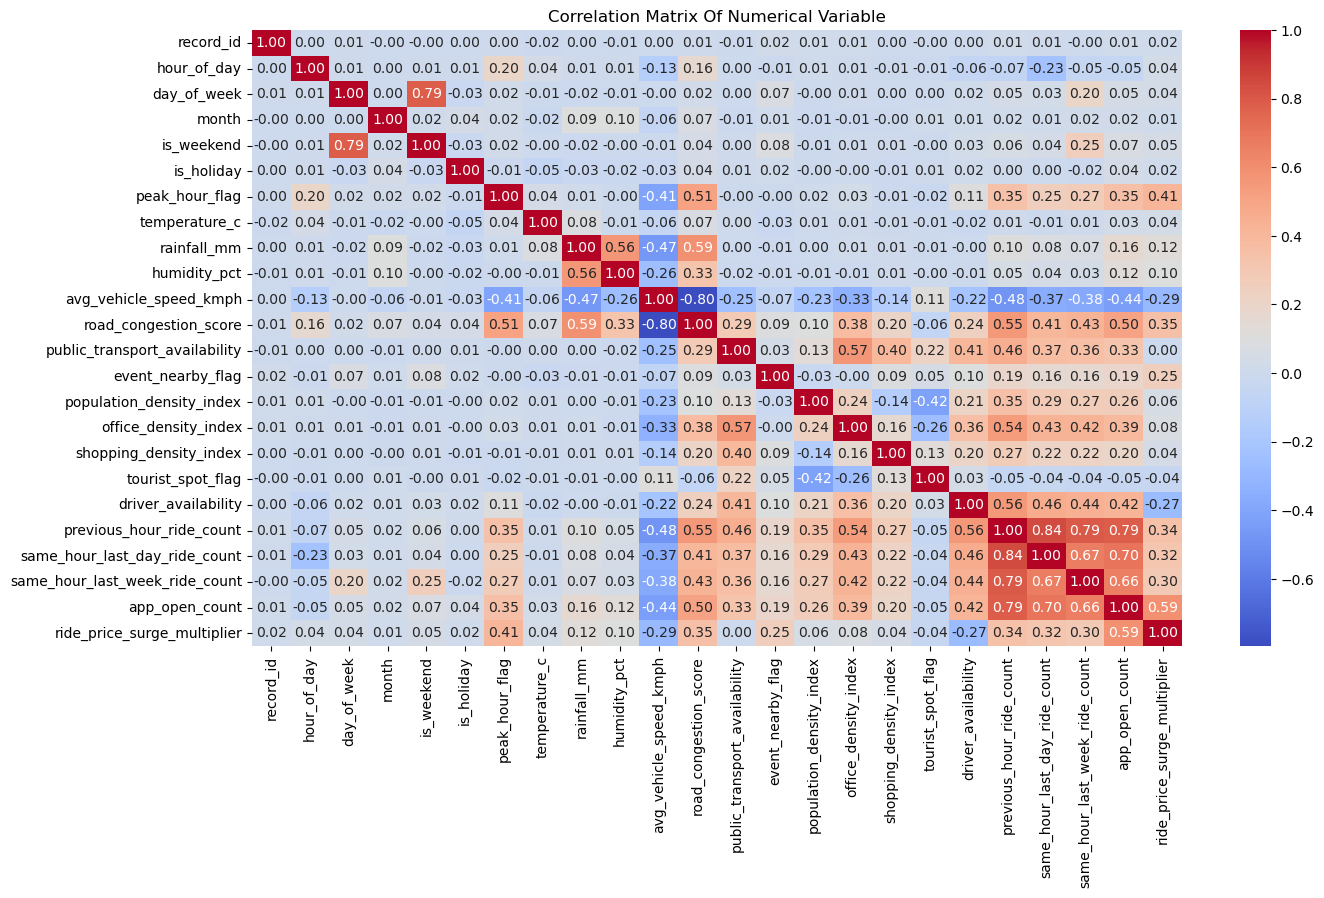

In [26]:
plt.figure(figsize=(15,8))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')
plt.title("Correlation Matrix Of Numerical Variable")
plt.show()


In [27]:
corr['previous_hour_ride_count'].sort_values(ascending=False)

previous_hour_ride_count          1.000000
same_hour_last_day_ride_count     0.841865
same_hour_last_week_ride_count    0.794470
app_open_count                    0.785380
driver_availability               0.556844
road_congestion_score             0.550943
office_density_index              0.537434
public_transport_availability     0.455093
population_density_index          0.347814
peak_hour_flag                    0.347246
ride_price_surge_multiplier       0.344950
shopping_density_index            0.272839
event_nearby_flag                 0.191973
rainfall_mm                       0.104008
is_weekend                        0.058509
humidity_pct                      0.053505
day_of_week                       0.045117
month                             0.017501
record_id                         0.012622
temperature_c                     0.010297
is_holiday                        0.004512
tourist_spot_flag                -0.046417
hour_of_day                      -0.071313
avg_vehicle

In [28]:
numerical_col=df.select_dtypes(include=['int64','float64'])
corr=numerical_col.corr()

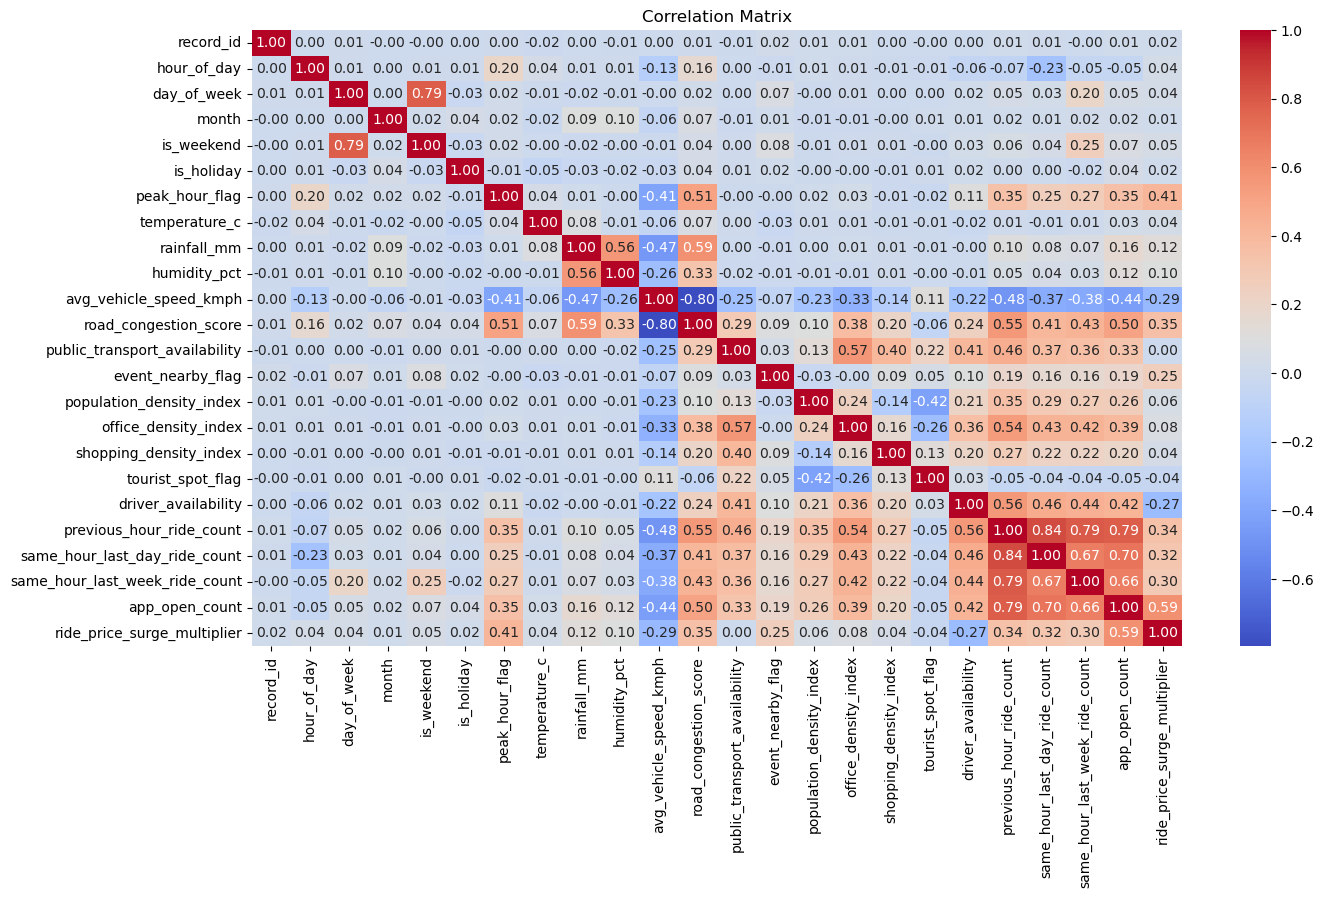

In [29]:
plt.figure(figsize=(15,8))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

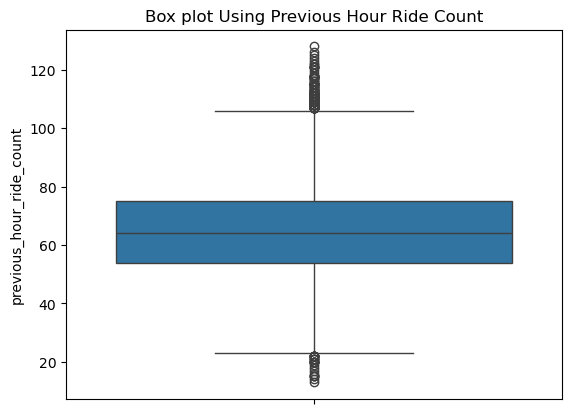

In [30]:
sns.boxplot(y='previous_hour_ride_count', data=df)
plt.title('Box plot Using Previous Hour Ride Count')
plt.show()


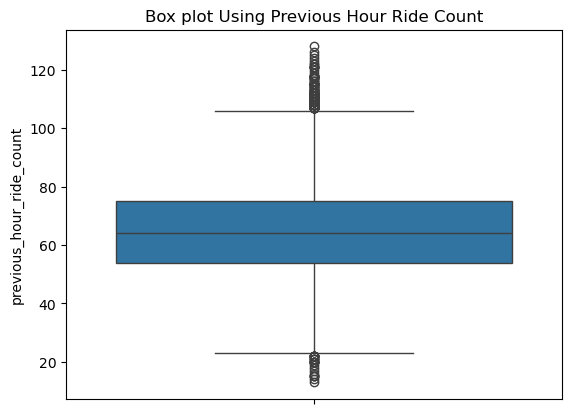

In [31]:
sns.boxplot(y='previous_hour_ride_count', data=df)
plt.title('Box plot Using Previous Hour Ride Count')
plt.show()


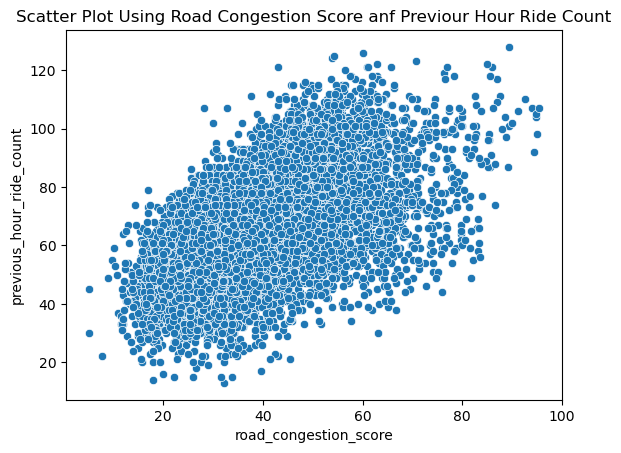

In [32]:
sns.scatterplot(x='road_congestion_score',y='previous_hour_ride_count',data=df)
plt.title('Scatter Plot Using Road Congestion Score anf Previour Hour Ride Count')
plt.show()

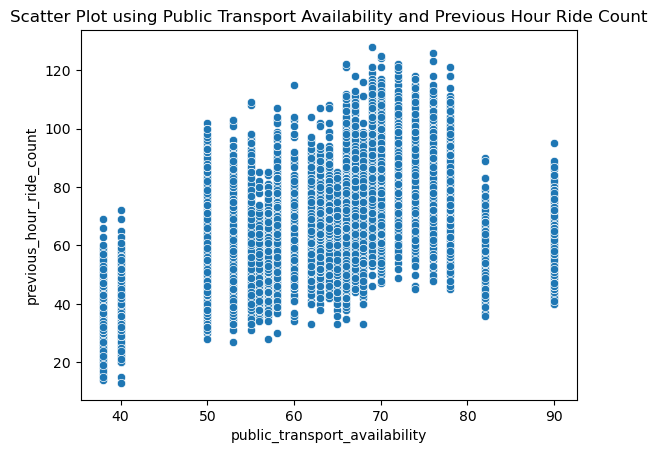

In [33]:
sns.scatterplot(x='public_transport_availability',y='previous_hour_ride_count',data=df)
plt.title('Scatter Plot using Public Transport Availability and Previous Hour Ride Count')
plt.show()

In [34]:
df[df['demand_zone']=="High"]['zone_id'].value_counts().head()

zone_id
Z005    199
Z004    195
Z018    164
Z006    158
Z025    154
Name: count, dtype: int64

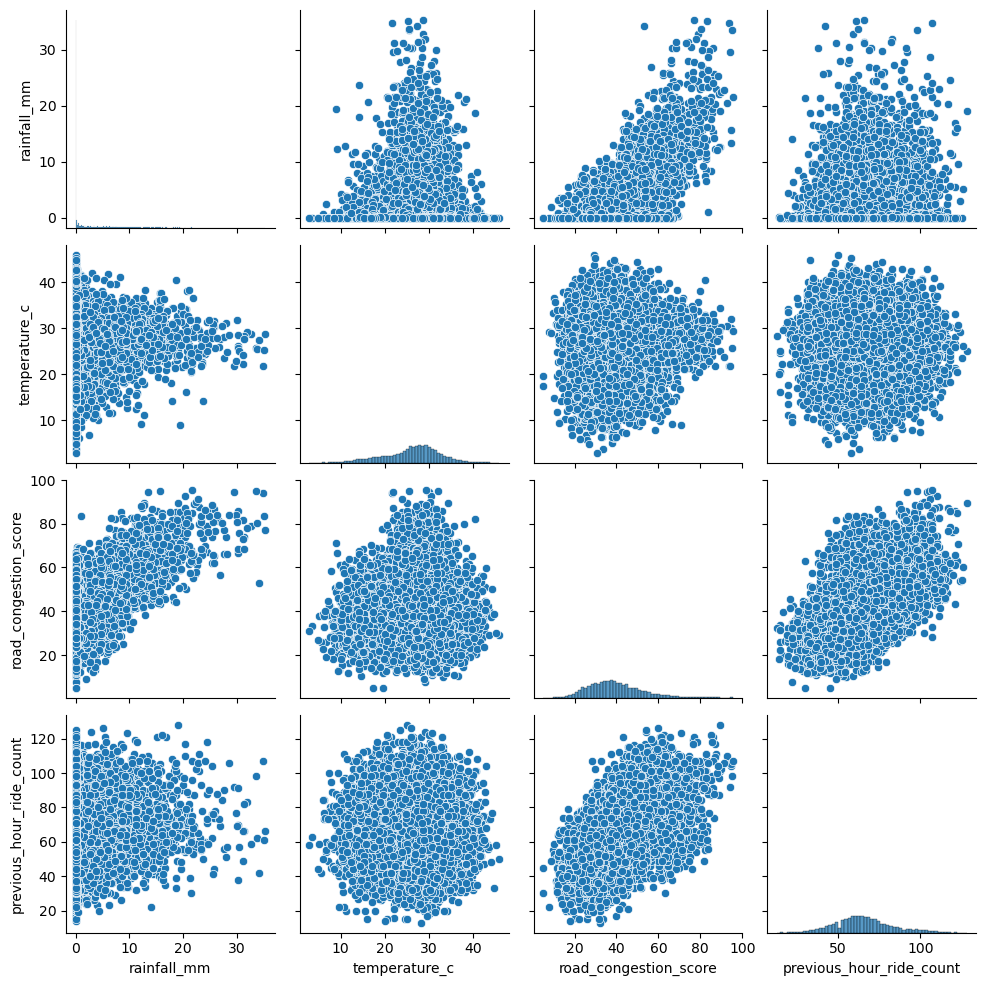

In [36]:
sns.pairplot(df[['rainfall_mm','temperature_c','road_congestion_score','previous_hour_ride_count']])
plt.show()

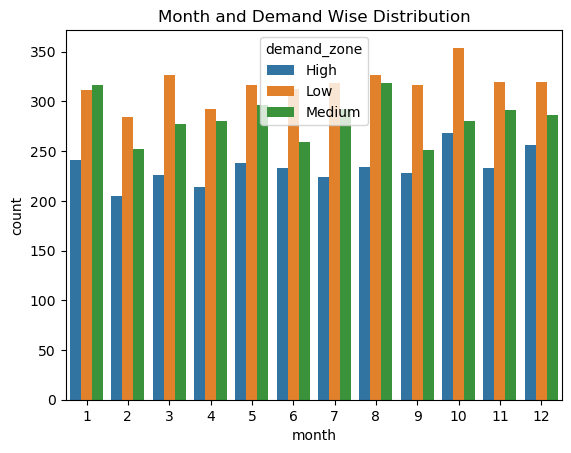

In [37]:
sns.countplot(x='month', hue='demand_zone', data=df)
plt.title('Month and Demand Wise Distribution')
plt.show()

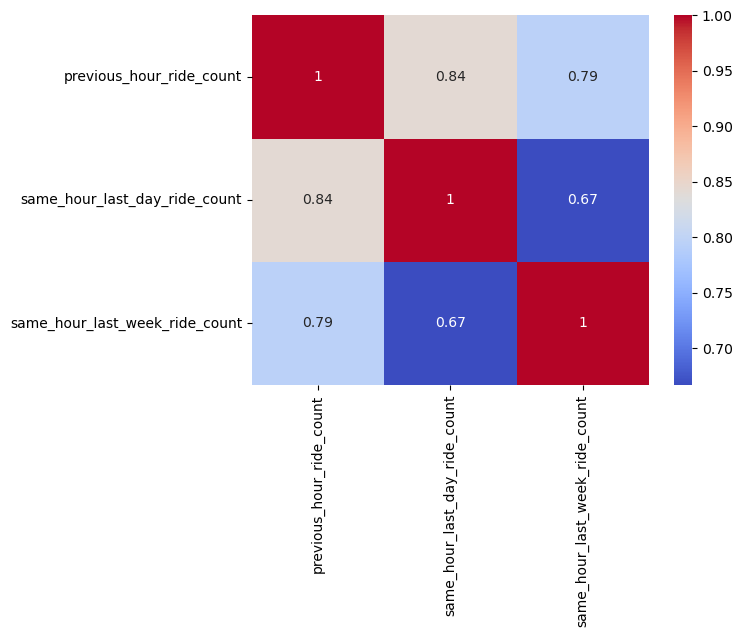

In [40]:
hist_features = df[['previous_hour_ride_count',
                    'same_hour_last_day_ride_count',
                    'same_hour_last_week_ride_count']]

sns.heatmap(hist_features.corr(),cmap='coolwarm', annot=True)
plt.show()

In [41]:
df.corr(numeric_only=True)['previous_hour_ride_count'].sort_values(ascending=False)

previous_hour_ride_count          1.000000
same_hour_last_day_ride_count     0.841865
same_hour_last_week_ride_count    0.794470
app_open_count                    0.785380
driver_availability               0.556844
road_congestion_score             0.550943
office_density_index              0.537434
public_transport_availability     0.455093
population_density_index          0.347814
peak_hour_flag                    0.347246
ride_price_surge_multiplier       0.344950
shopping_density_index            0.272839
event_nearby_flag                 0.191973
rainfall_mm                       0.104008
is_weekend                        0.058509
humidity_pct                      0.053505
day_of_week                       0.045117
month                             0.017501
record_id                         0.012622
temperature_c                     0.010297
is_holiday                        0.004512
tourist_spot_flag                -0.046417
hour_of_day                      -0.071313
avg_vehicle

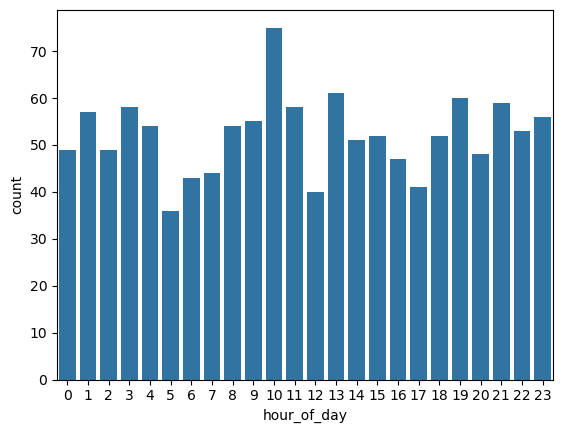

In [42]:
business = df[df['zone_type']=="Commercial"]
sns.countplot(x='hour_of_day', data=business)
plt.show()


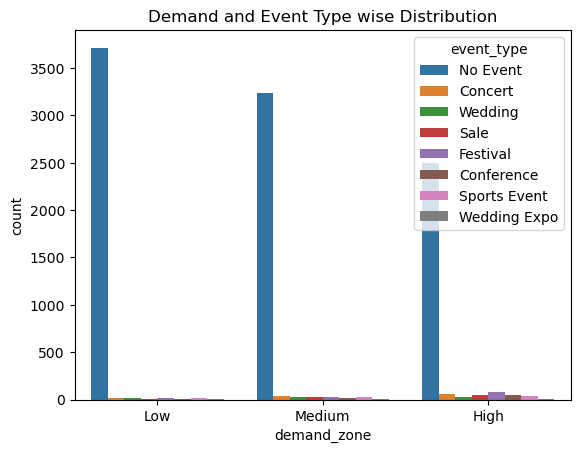

In [43]:
sns.countplot(x='demand_zone',hue='event_type',data=df)
plt.title('Demand and Event Type wise Distribution')
plt.show()

In [44]:
def peak_hour(x):
    if x >= 7 and x <= 9:
        return 1
    elif x >= 17 and x <= 19:
        return 1
    else:
        return 0

df['peak_hour'] = df['hour_of_day'].apply(peak_hour)

In [45]:
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['hour_of_day'].apply(get_time_of_day)

In [46]:
df['demand_pressure_ratio'] = (df['previous_hour_ride_count'] / (df['driver_availability'] + 1))

In [47]:
df['zone_activity_score'] = (df['population_density_index'] +df['office_density_index'] +df['shopping_density_index'])

In [48]:
df['zone_activity_score'] = (df['population_density_index'] +df['office_density_index'] +df['shopping_density_index'])

In [49]:
df['historical_demand_index'] = (df['previous_hour_ride_count'] +df['same_hour_last_day_ride_count'] +df['same_hour_last_week_ride_count']) / 3

In [50]:
df['congestion_weather_interaction']=(df['road_congestion_score']/df['rainfall_mm'])

Encoding

In [77]:
df.head()

,zone_type,hour_of_day,day_of_week,month,is_weekend,is_holiday,peak_hour_flag,weather_condition,temperature_c,rainfall_mm,...,same_hour_last_week_ride_count,app_open_count,ride_price_surge_multiplier,demand_zone,peak_hour,time_of_day,demand_pressure_ratio,zone_activity_score,historical_demand_index,congestion_weather_interaction
0,9,22,3,10,0,0,0,4,27.6,2.2,...,31,106,1.22,1,0,Night,2.086957,68,36.333333,10.045455
1,1,4,3,5,0,0,0,1,28.6,0.0,...,41,111,1.00,2,0,Night,1.235294,213,66.333333,inf
2,8,3,2,12,0,0,0,0,13.6,0.0,...,60,109,1.13,0,0,Night,2.166667,130,57.333333,inf
3,6,22,3,12,0,0,0,5,18.4,8.2,...,40,113,1.12,2,0,Night,1.259259,176,53.666667,6.865854
4,7,2,5,8,1,0,0,1,27.0,0.9,...,45,66,0.92,2,0,Night,0.948276,135,47.666667,37.777778


In [101]:
df.select_dtypes(include="object").columns

Index(['time_of_day'], dtype='object')

In [102]:
from sklearn.preprocessing import LabelEncoder

In [103]:
le = LabelEncoder()

In [104]:
df["zone_type"] = le.fit_transform(df["zone_type"])
df["weather_condition"] = le.fit_transform(df["weather_condition"])
df["event_type"] = le.fit_transform(df["event_type"])
df["traffic_level"] = le.fit_transform(df["traffic_level"])

In [105]:
df.head()

,zone_type,hour_of_day,day_of_week,month,is_weekend,is_holiday,peak_hour_flag,weather_condition,temperature_c,rainfall_mm,...,same_hour_last_week_ride_count,app_open_count,ride_price_surge_multiplier,demand_zone,peak_hour,time_of_day,demand_pressure_ratio,zone_activity_score,historical_demand_index,congestion_weather_interaction
0,9,22,3,10,0,0,0,4,27.6,2.2,...,31,106,1.22,1,0,Night,2.086957,68,36.333333,10.045455
1,1,4,3,5,0,0,0,1,28.6,0.0,...,41,111,1.00,2,0,Night,1.235294,213,66.333333,inf
2,8,3,2,12,0,0,0,0,13.6,0.0,...,60,109,1.13,0,0,Night,2.166667,130,57.333333,inf
3,6,22,3,12,0,0,0,5,18.4,8.2,...,40,113,1.12,2,0,Night,1.259259,176,53.666667,6.865854
4,7,2,5,8,1,0,0,1,27.0,0.9,...,45,66,0.92,2,0,Night,0.948276,135,47.666667,37.777778


In [106]:
df = pd.get_dummies(
    df,
    columns=[
        "zone_type",
        "weather_condition",
        "event_type",
        "traffic_level"
    ],
    drop_first=True
)

In [107]:
df.head()

,hour_of_day,day_of_week,month,is_weekend,is_holiday,peak_hour_flag,temperature_c,rainfall_mm,humidity_pct,avg_vehicle_speed_kmph,...,event_type_1,event_type_2,event_type_3,event_type_4,event_type_5,event_type_6,event_type_7,traffic_level_1,traffic_level_2,traffic_level_3
0,22,3,10,0,0,0,27.6,2.2,82.6,48.9,...,False,False,True,False,False,False,False,True,False,False
1,4,3,5,0,0,0,28.6,0.0,71.6,48.7,...,False,False,True,False,False,False,False,True,False,False
2,3,2,12,0,0,0,13.6,0.0,56.7,37.3,...,False,False,True,False,False,False,False,True,False,False
3,22,3,12,0,0,0,18.4,8.2,76.6,25.9,...,False,False,True,False,False,False,False,False,False,False
4,2,5,8,1,0,0,27.0,0.9,56.2,34.7,...,False,False,True,False,False,False,False,False,True,False


In [108]:
df["demand_zone"] = df["demand_zone"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

In [109]:
df["demand_zone"].value_counts()

Series([], Name: count, dtype: int64)

In [116]:
df["demand_zone"].isnull().sum()

np.int64(10000)

In [117]:
df.head()

,hour_of_day,day_of_week,month,is_weekend,is_holiday,peak_hour_flag,temperature_c,rainfall_mm,humidity_pct,avg_vehicle_speed_kmph,...,event_type_1,event_type_2,event_type_3,event_type_4,event_type_5,event_type_6,event_type_7,traffic_level_1,traffic_level_2,traffic_level_3
0,22,3,10,0,0,0,27.6,2.2,82.6,48.9,...,False,False,True,False,False,False,False,True,False,False
1,4,3,5,0,0,0,28.6,0.0,71.6,48.7,...,False,False,True,False,False,False,False,True,False,False
2,3,2,12,0,0,0,13.6,0.0,56.7,37.3,...,False,False,True,False,False,False,False,True,False,False
3,22,3,12,0,0,0,18.4,8.2,76.6,25.9,...,False,False,True,False,False,False,False,False,False,False
4,2,5,8,1,0,0,27.0,0.9,56.2,34.7,...,False,False,True,False,False,False,False,False,True,False
